In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import copy

############################################
# Setup
############################################
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

############################################
# Dataset (MNIST)
############################################
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset  = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

train_loader  = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader   = torch.utils.data.DataLoader(dataset=test_dataset,  batch_size=1000, shuffle=False)

############################################
# Simple MLP Model
############################################
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=128, output_dim=10):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

############################################
# Evaluation Functions
############################################
def evaluate_loss(models, loader):
    criterion = nn.CrossEntropyLoss()
    total_loss, total_count = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs_sum = sum(m(images) for m in models)
            outputs_avg = outputs_sum / len(models)
            loss = criterion(outputs_avg, labels).item()
            total_loss += loss * images.size(0)
            total_count += images.size(0)
    return total_loss / total_count

def evaluate_accuracy(models, loader):
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs_sum = sum(m(images) for m in models)
            outputs_avg = outputs_sum / len(models)
            _, predicted = torch.max(outputs_avg, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

############################################
# Helper: Compute Gradients for Each Particle
############################################
def compute_particle_grads(models, images, labels, accumulators, method):
    grads_list = []
    for i, model in enumerate(models):
        model.zero_grad()
        outputs = model(images)
        loss = nn.functional.cross_entropy(outputs, labels)
        loss.backward()

        grad_dict = {}
        for name, p in model.named_parameters():
            if p.grad is None:
                continue
            g = p.grad.data.clone()

            # For Adagrad, accumulate and scale
            if method == 'adagrad':
                accumulators[i][name].add_(g.pow(2))
                adagrad_scale = 1.0 / (accumulators[i][name].sqrt() + 1e-8)
                g = g * adagrad_scale

            grad_dict[name] = g
        grads_list.append(grad_dict)
    return grads_list

############################################
# Main Experiment Function
############################################
def run_particle_experiment(method='sgd',
                            eta=0.1,
                            tau=0.0,
                            f_func=lambda x: x,
                            epsilon=1.0,
                            num_particles=5,
                            num_epochs=20,
                            with_LM=True,
                            avg_grad=False):
    """
    Runs an experiment for:
      - method: 'sgd' or 'adagrad' (could also support 'npgd')
      - eta: step size
      - tau: noise coefficient (only if 'npgd')
      - f_func: transform for (loss - c_k)
      - epsilon: small constant in denom
      - num_particles: number of models in the ensemble
      - num_epochs: training epochs
      - with_LM: landscape modification
      - avg_grad: if True, apply the average gradient across all particles
                  else each particle updates with its own gradient.
    """
    # 1) Create ensemble
    models = [SimpleMLP().to(device) for _ in range(num_particles)]
    init_state = copy.deepcopy(models[0].state_dict())
    for m in models:
        m.load_state_dict(init_state)

    # 2) Build accumulators if Adagrad
    accumulators = []
    if method == 'adagrad':
        for m in models:
            accum = {}
            for name, p in m.named_parameters():
                accum[name] = torch.zeros_like(p.data)
            accumulators.append(accum)
    else:
        accumulators = [None] * num_particles

    # 3) Track losses
    train_losses, test_losses = [], []

    # 4) Training loop
    for epoch in range(num_epochs):
        epoch_loss_sum = 0.0
        batch_count = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # If LM, compute c_k based on current average loss across particles
            if with_LM:
                with torch.no_grad():
                    losses = [nn.functional.cross_entropy(m(images), labels).item()
                              for m in models]
                c_k = np.mean(losses)
            else:
                c_k = 0.0

            # Compute all grads
            grads_list = compute_particle_grads(models, images, labels, accumulators, method)

            with torch.no_grad():
                losses = [nn.functional.cross_entropy(m(images), labels).item()
                          for m in models]
            avg_loss = np.mean(losses)

            if with_LM:
                denom_val = f_func(max(0.0, avg_loss - c_k)) + epsilon
            else:
                denom_val = 1

            # Update parameters
            if avg_grad:
                # 1) Compute average gradient
                num_p = len(models)
                avg_grads = {}
                for name in grads_list[0].keys():
                    avg_grads[name] = sum(g[name] for g in grads_list) / float(num_p)
                # 2) Apply same update to each model
                with torch.no_grad():
                    for m in models:
                        for name, p in m.named_parameters():
                            g = avg_grads[name] / denom_val
                            if method == 'npgd':
                                noise = torch.randn_like(p) * (2.0 * eta * tau)**0.5
                            else:
                                noise = 0.0
                            p.data = p.data - eta * g + noise
            else:
                # Update each particle with its own gradient
                for i, model in enumerate(models):
                    with torch.no_grad():
                        for name, p in model.named_parameters():
                            g = grads_list[i][name] / denom_val
                            if method == 'npgd':
                                noise = torch.randn_like(p) * (2.0 * eta * tau)**0.5
                            else:
                                noise = 0.0
                            p.data = p.data - eta * g + noise

            epoch_loss_sum += avg_loss
            batch_count += 1

        train_loss_epoch = epoch_loss_sum / batch_count
        train_losses.append(train_loss_epoch)
        test_losses.append(evaluate_loss(models, test_loader))

        print(f"[{method.upper()}{'-LM' if with_LM else ''}"
              f"{'-AVG' if avg_grad else '-INDIV'}] "
              f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss = {train_loss_epoch:.4f}, "
              f"Test Loss = {test_losses[-1]:.4f}")

    # Final accuracy
    acc = evaluate_accuracy(models, test_loader)
    return train_losses, test_losses, acc

############################################
# Running All 8 Groups × 4 Particle Counts
############################################
methods = ['sgd', 'adagrad']          # 2
landscape_mods = [True, False]       # 2
avg_flags = [False, True]            # 2
particle_counts = [1, 2, 5, 10]      # 4

results = {}
num_epochs = 10

for method in methods:
    for lm_flag in landscape_mods:
        for avg_flag in avg_flags:
            for nP in particle_counts:
                key = (method, lm_flag, avg_flag, nP)
                print("\n=== Running", key, "===")
                train_losses, test_losses, acc = run_particle_experiment(
                    method=method,
                    eta=0.1 if method=='sgd' else 0.01,
                    tau=0.0,
                    f_func=lambda x: x,
                    epsilon=1.0,
                    num_particles=nP,
                    num_epochs=num_epochs,
                    with_LM=lm_flag,
                    avg_grad=avg_flag
                )
                results[key] = (train_losses, test_losses, acc)


print("\n=== Final Accuracies on MNIST ===")
for (method, lm_flag, avg_flag, nP), (train_losses, test_losses, acc) in results.items():
    method_str = f"{method.upper()}"
    method_str += "-LM" if lm_flag else "-NoLM"
    method_str += "-AVG" if avg_flag else "-INDIV"
    print(f"{method_str}, nP={nP}, Acc={acc:.2f}%")


cpu

=== Running ('sgd', True, False, 1) ===
[SGD-LM-INDIV] Epoch 1/10: Train Loss = 0.2574, Test Loss = 0.1401
[SGD-LM-INDIV] Epoch 2/10: Train Loss = 0.1110, Test Loss = 0.1010
[SGD-LM-INDIV] Epoch 3/10: Train Loss = 0.0774, Test Loss = 0.0902
[SGD-LM-INDIV] Epoch 4/10: Train Loss = 0.0596, Test Loss = 0.0783


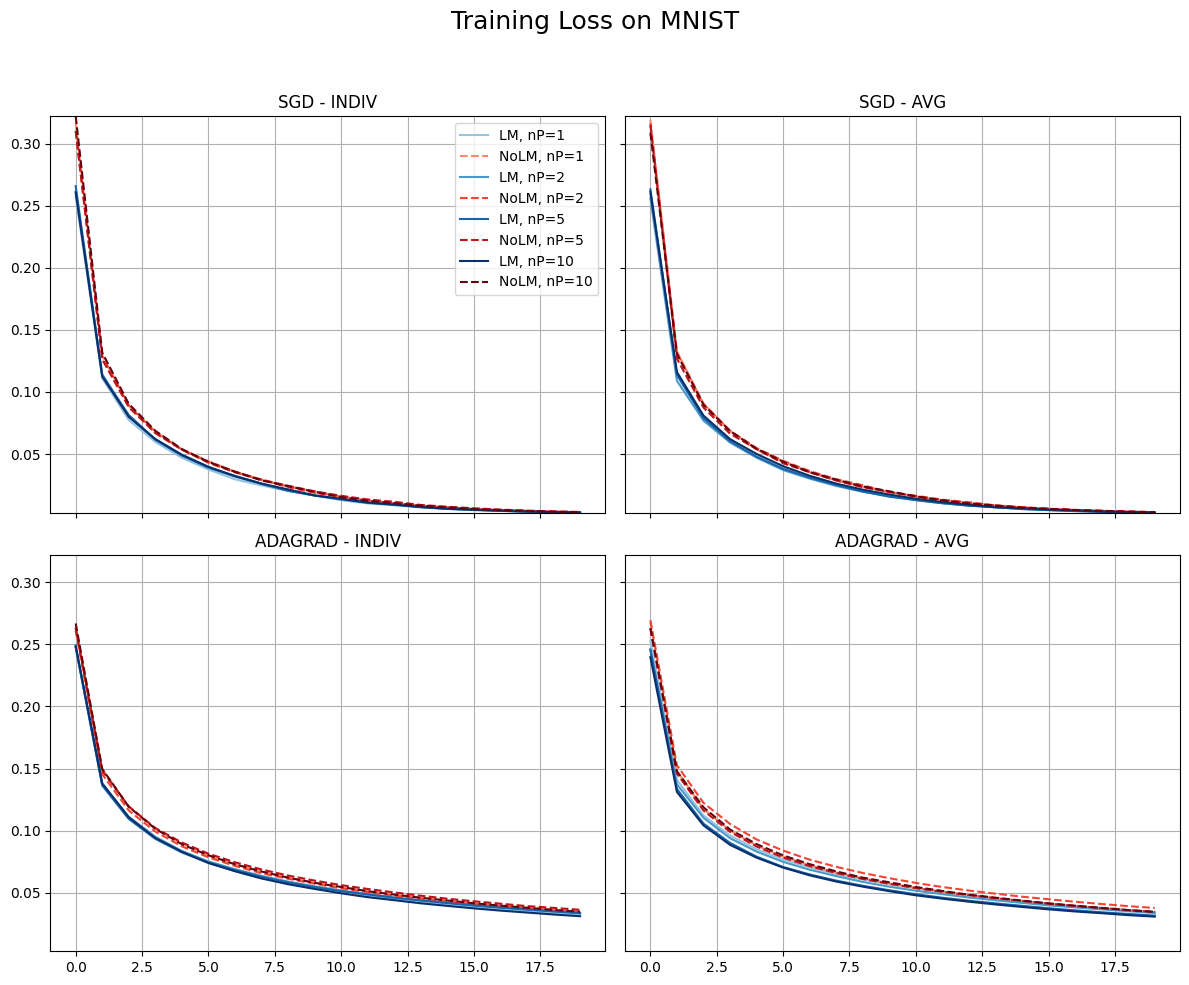

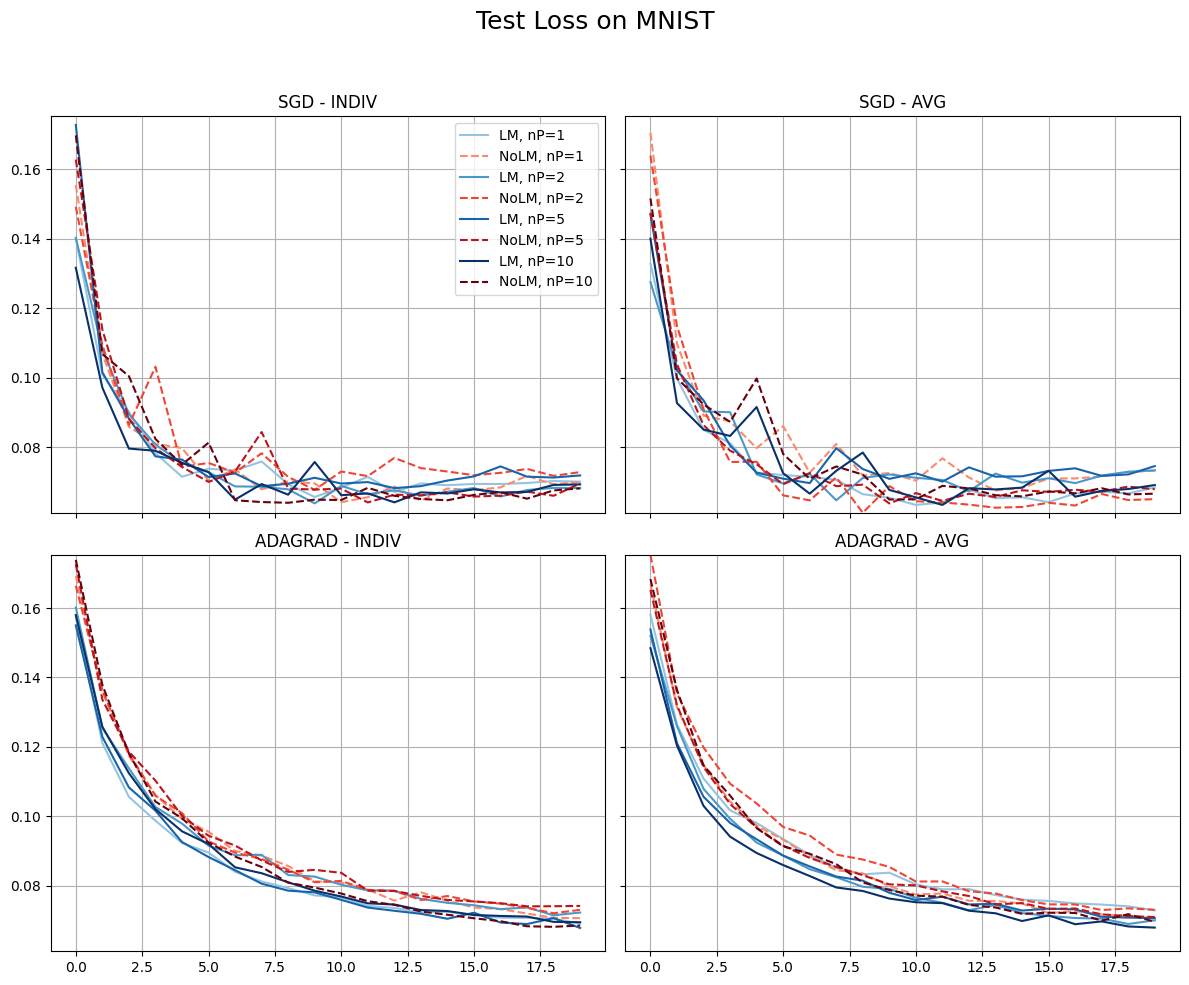

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Compute y-axis bounds
all_train_values = []
all_test_values = []
for v in results.values():
    train_losses, test_losses, _ = v
    all_train_values.extend(train_losses)
    all_test_values.extend(test_losses)

ymin_train, ymax_train = min(all_train_values), max(all_train_values)
ymin_test, ymax_test = min(all_test_values), max(all_test_values)

# Define color maps
colors_lm = plt.cm.Blues(np.linspace(0.4, 1.0, len(particle_counts)))
colors_no_lm = plt.cm.Reds(np.linspace(0.4, 1.0, len(particle_counts)))

# Plot training loss
fig_train, axes_train = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), sharex=True, sharey=True)
axes_train = axes_train.flatten()
fig_train.suptitle("Training Loss on MNIST", fontsize=18)

for idx, (method, avg_flag) in enumerate([(m, a) for m in methods for a in avg_flags]):
    ax = axes_train[idx]
    for i, nP in enumerate(particle_counts):
        train_lm, _, _ = results[(method, True, avg_flag, nP)]
        train_no_lm, _, _ = results[(method, False, avg_flag, nP)]
        ax.plot(train_lm, label=f"LM, nP={nP}", color=colors_lm[i])
        ax.plot(train_no_lm, label=f"NoLM, nP={nP}", color=colors_no_lm[i], linestyle='--')

    ax.set_title(f"{method.upper()} - {'AVG' if avg_flag else 'INDIV'}", fontsize=12)
    ax.set_ylim([ymin_train, ymax_train])
    ax.grid(True)
    if idx == 0:
        ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Plot test loss
fig_test, axes_test = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), sharex=True, sharey=True)
axes_test = axes_test.flatten()
fig_test.suptitle("Test Loss on MNIST", fontsize=18)

for idx, (method, avg_flag) in enumerate([(m, a) for m in methods for a in avg_flags]):
    ax = axes_test[idx]
    for i, nP in enumerate(particle_counts):
        _, test_lm, _ = results[(method, True, avg_flag, nP)]
        _, test_no_lm, _ = results[(method, False, avg_flag, nP)]
        ax.plot(test_lm, label=f"LM, nP={nP}", color=colors_lm[i])
        ax.plot(test_no_lm, label=f"NoLM, nP={nP}", color=colors_no_lm[i], linestyle='--')

    ax.set_title(f"{method.upper()} - {'AVG' if avg_flag else 'INDIV'}", fontsize=12)
    ax.set_ylim([ymin_test, ymax_test])
    ax.grid(True)
    if idx == 0:
        ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()